<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/PCA_face_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA as RandomizedPCA
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Load dataset
faces = fetch_lfw_people(min_faces_per_person=60)

In [ ]:
# Train PCA
pca = RandomizedPCA(1100)
pca.fit(faces.data)

PCA(n_components=1100)

In [ ]:
# Load image
import random

try:
    img = Image.open('face.png').convert('L')
except FileNotFoundError:

    # Assuming faces.images is available from previous cells.
    # It contains images as numpy arrays, which are typically float32.
    random_index = random.randint(0, len(faces.images) - 1)
    img_array_float = faces.images[random_index] # Get the float array
    # Scale float array from [0, 1] to [0, 255] and then convert to uint8
    # This is important for Pillow to correctly interpret the grayscale image.
    img = Image.fromarray((img_array_float * 255).astype(np.uint8))

In [ ]:
# Resize image
img = img.resize((47, 62))

In [ ]:
# Convert image to array
img_array = np.array(img)

In [ ]:
# Flatten image
img_flat = img_array.reshape(1, -1)

In [ ]:
# Reconstruct image
components = pca.transform(img_flat)
projected = pca.inverse_transform(components)

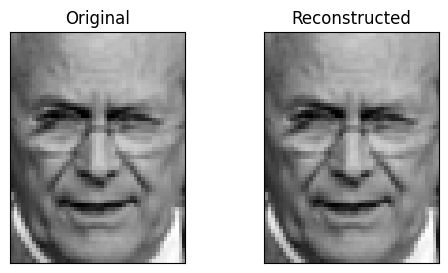

In [ ]:
# Plot
fig, ax = plt.subplots(1, 2, figsize=(6,3),
                       subplot_kw={'xticks':[], 'yticks':[]})

ax[0].imshow(img_array, cmap='binary_r')
ax[0].set_title('Original')

ax[1].imshow(projected.reshape(62,47), cmap='binary_r')
ax[1].set_title('Reconstructed')

plt.show()